# Ensemble Learning Practice
## Monday, January 26, 2026

---

In this notebook, we'll put ensemble learning into practice!

**Structure:**
- **Part A: Guided Walkthrough** - We'll work through ensemble methods together using the Titanic dataset
- **Part B: Challenge Extension** - Push your skills further by improving your model performance

---

# Part A: Guided Walkthrough (Titanic Dataset)

Can we predict who survived the Titanic disaster? Follow along as we explore different ensemble techniques!

## 1. Setup & Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Individual models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Ensemble methods
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Titanic dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(titanic_url)

print("Titanic Dataset Shape:", titanic.shape)
titanic.head()

Titanic Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Quick look at the data
print("Dataset Info:")
print(f"Total passengers: {len(titanic)}")
print(f"Survived: {titanic['Survived'].sum()} ({titanic['Survived'].mean()*100:.1f}%)")
print(f"Did not survive: {len(titanic) - titanic['Survived'].sum()} ({(1-titanic['Survived'].mean())*100:.1f}%)")

Dataset Info:
Total passengers: 891
Survived: 342 (38.4%)
Did not survive: 549 (61.6%)


In [4]:
# Data preparation
# Select features and handle missing values

# Features we'll use
titanic_clean = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

# Fill missing Age with median
titanic_clean['Age'].fillna(titanic_clean['Age'].median(), inplace=True)

# Convert Sex to numeric
titanic_clean['Sex'] = titanic_clean['Sex'].map({'male': 0, 'female': 1})

# Check for any remaining missing values
print("Missing values:")
print(titanic_clean.isnull().sum())
print(f"\nDataset shape: {titanic_clean.shape}")

Missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

Dataset shape: (891, 7)


In [5]:
# Prepare features (X) and target (y)
X = titanic_clean.drop('Survived', axis=1)
y = titanic_clean['Survived']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features - important for distance-based algorithms like KNN!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nFeatures have been scaled using StandardScaler!")

Training set size: 623
Test set size: 268

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

Features have been scaled using StandardScaler!


## 2. Baseline: Individual Models

Before we build ensembles, let's see how individual models perform.

In [6]:
# Create individual models
log_reg = LogisticRegression(max_iter=200, random_state=42)
decision_tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# Train and evaluate each model (using scaled features)
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': decision_tree,
    'KNN': knn
}

print("Individual Model Performance:")
print("=" * 40)

individual_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    individual_results[name] = accuracy
    print(f"{name}: {accuracy:.4f}")

Individual Model Performance:
Logistic Regression: 0.8134
Decision Tree: 0.7724
KNN: 0.8172


## 3. Voting Classifier

Now let's combine these models using voting! 

**Important note:** Voting is the *simplest* ensemble technique. It doesn't always beat the best individual model - it depends on how diverse and accurate the base models are. Let's see what happens with our models!

### Hard Voting
Each model votes for a class, and the majority wins.

In [8]:
# Create a Hard Voting Classifier
hard_voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=200, random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='hard'  # Majority voting
)

# Train and evaluate (using scaled features)
hard_voting.fit(X_train_scaled, y_train)
y_pred_hard = hard_voting.predict(X_test_scaled)
hard_accuracy = accuracy_score(y_test, y_pred_hard)

print(f"Hard Voting Accuracy: {hard_accuracy:.4f}")
print(f"Best individual model: {max(individual_results.values()):.4f}")

Hard Voting Accuracy: 0.8246
Best individual model: 0.8172


### Soft Voting
Each model provides probability scores, and we average them.

In [9]:
# Create a Soft Voting Classifier
soft_voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=200, random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ],
    voting='soft'  # Average probabilities
)

# Train and evaluate (using scaled features)
soft_voting.fit(X_train_scaled, y_train)
y_pred_soft = soft_voting.predict(X_test_scaled)
soft_accuracy = accuracy_score(y_test, y_pred_soft)

print(f"Soft Voting Accuracy: {soft_accuracy:.4f}")

Soft Voting Accuracy: 0.8134


### Compare Voting Results

In [10]:
# Summary comparison
print("\nVoting Classifier Comparison:")
print("=" * 40)
print(f"Hard Voting: {hard_accuracy:.4f}")
print(f"Soft Voting: {soft_accuracy:.4f}")
print(f"\nBest individual model was: {max(individual_results, key=individual_results.get)}")
print(f"Best individual accuracy: {max(individual_results.values()):.4f}")

# Check if voting improved over best individual
best_voting = max(hard_accuracy, soft_accuracy)
best_individual = max(individual_results.values())

print("\n" + "-" * 40)
if best_voting > best_individual:
    print("Voting improved over the best individual model!")
    print("This shows the power of combining diverse models.")
else:
    print("Voting didn't beat the best individual model here.")
    print("This can happen - ensembles don't always guarantee")
    print("improvement, especially with similar base models.")
print("\nLet's see how other ensemble methods perform...")


Voting Classifier Comparison:
Hard Voting: 0.8246
Soft Voting: 0.8134

Best individual model was: KNN
Best individual accuracy: 0.8172

----------------------------------------
Voting improved over the best individual model!
This shows the power of combining diverse models.

Let's see how other ensemble methods perform...


## 4. Bagging with Random Forest

Random Forest = Bagging + Decision Trees + Random Feature Selection

Instead of combining different algorithms, we train many decision trees on different random subsets of the data.

**Note:** Tree-based models (Decision Tree, Random Forest, Gradient Boosting) don't require feature scaling, so we'll use the original unscaled data for these methods. This is one of their advantages!

In [11]:
# Compare single Decision Tree vs Random Forest
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
single_tree_acc = accuracy_score(y_test, single_tree.predict(X_test))

print(f"Single Decision Tree Accuracy: {single_tree_acc:.4f}")

Single Decision Tree Accuracy: 0.7612


In [12]:
# Train Random Forest with different n_estimators
n_estimators_list = [10, 50, 100, 200]

print("\nRandom Forest Performance by n_estimators:")
print("=" * 45)

rf_results = {}
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test))
    rf_results[n] = rf_acc
    print(f"n_estimators={n:3d}: {rf_acc:.4f}")

print(f"\nSingle Tree:      {single_tree_acc:.4f}")
print(f"Best RF improvement: +{max(rf_results.values()) - single_tree_acc:.4f}")


Random Forest Performance by n_estimators:
n_estimators= 10: 0.7799
n_estimators= 50: 0.7761
n_estimators=100: 0.7836
n_estimators=200: 0.7873

Single Tree:      0.7612
Best RF improvement: +0.0261


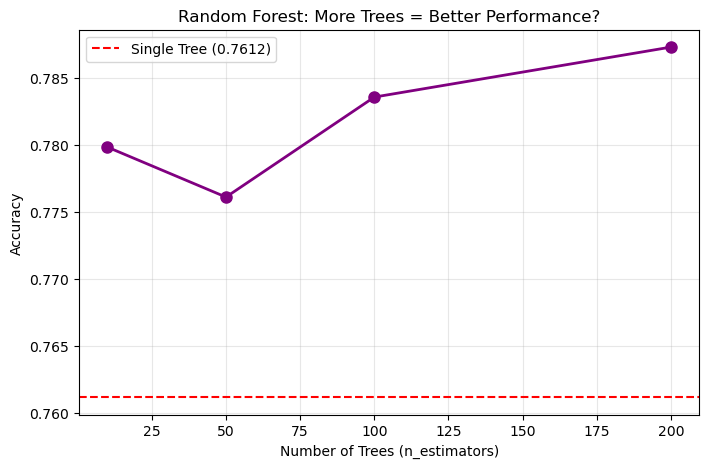

In [13]:
# Visualize Random Forest performance
plt.figure(figsize=(8, 5))
plt.plot(list(rf_results.keys()), list(rf_results.values()), marker='o', linewidth=2, markersize=8, color='purple')
plt.axhline(y=single_tree_acc, color='red', linestyle='--', label=f'Single Tree ({single_tree_acc:.4f})')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest: More Trees = Better Performance?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

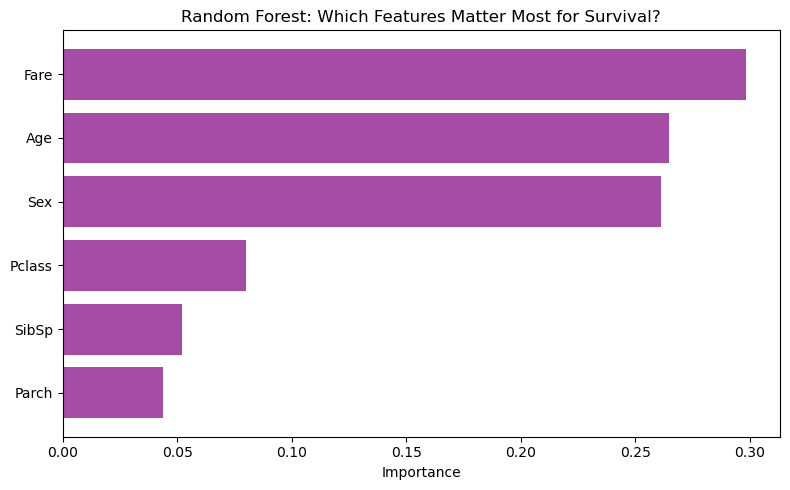


Feature Importances:
Feature  Importance
   Fare    0.298234
    Age    0.264629
    Sex    0.261018
 Pclass    0.080005
  SibSp    0.052092
  Parch    0.044023


In [16]:
# Feature Importances from Random Forest
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

# Get feature importances
importances = rf_final.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple', alpha=0.7)
plt.xlabel('Importance')
plt.title('Random Forest: Which Features Matter Most for Survival?')
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

### Random Forest Takeaways

**What we learned:**
- **More trees generally = better performance**, but with diminishing returns (notice how 100 trees isn't much better than 50)
- **Random Forest significantly outperforms a single Decision Tree** - this is the power of bagging!
- **Feature importance** tells us which features the model relies on most. For Titanic, Sex and Fare are typically the strongest predictors (historically, "women and children first" and wealth = better cabin location)

**When to use Random Forest:**
- When you want a robust, accurate model that's hard to overfit
- When you need feature importance rankings
- When you have tabular data and don't need extensive hyperparameter tuning

## 5. Boosting with Gradient Boosting

Boosting builds models sequentially, with each model learning from the previous model's mistakes.

In [17]:
# Train Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))

print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")

Gradient Boosting Accuracy: 0.8172


### Gradient Boosting Takeaways

**What we learned:**
- **Boosting learns from mistakes** - each new tree focuses on the errors of the previous trees
- **Gradient Boosting often matches or beats Random Forest** - especially when properly tuned
- **Sequential training** means it can be slower than Random Forest (which trains trees in parallel)

**Bagging vs Boosting:**
| Bagging (Random Forest) | Boosting (Gradient Boosting) |
|------------------------|------------------------------|
| Trains trees in parallel | Trains trees sequentially |
| Reduces variance (overfitting) | Reduces bias (underfitting) |
| More robust to noise | Can overfit if not tuned |
| Faster to train | Often more accurate |

In [18]:
# Compare Bagging vs Boosting
print("\nBagging vs Boosting Comparison:")
print("=" * 45)
print(f"Single Decision Tree:     {single_tree_acc:.4f}")
print(f"Random Forest (Bagging):  {rf_results[100]:.4f}")
print(f"Gradient Boosting:        {gb_acc:.4f}")


Bagging vs Boosting Comparison:
Single Decision Tree:     0.7612
Random Forest (Bagging):  0.7836
Gradient Boosting:        0.8172


### XGBoost Takeaways

**What we learned:**
- **XGBoost is an optimized version of Gradient Boosting** - faster and often more accurate
- **Extremely popular in industry and competitions** - it's a go-to algorithm for tabular data
- **Built-in regularization** helps prevent overfitting

**Why XGBoost is special:**
- Handles missing values automatically
- Built-in cross-validation
- Parallel processing for speed
- Regularization to prevent overfitting
- Used by many winning Kaggle solutions!

**Fun fact:** This is the first algorithm Abishek built from scratch in production - used to predict mental health conditions and find optimal treatments!

## 6. XGBoost

XGBoost is an optimized implementation of Gradient Boosting that's extremely popular in competitions and industry.

In [20]:
# Install XGBoost if needed (uncomment if not installed)
# !pip install xgboost

try:
    from xgboost import XGBClassifier
    
    # Train XGBoost
    xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
    
    print(f"XGBoost Accuracy: {xgb_acc:.4f}")
    
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")
    xgb_acc = None

XGBoost Accuracy: 0.8022


## Final Comparison: All Methods

In [22]:
# Create a summary of all methods
results = {
    'Logistic Regression': individual_results['Logistic Regression'],
    'Decision Tree': individual_results['Decision Tree'],
    'KNN': individual_results['KNN'],
    'Hard Voting': hard_accuracy,
    'Soft Voting': soft_accuracy,
    'Random Forest': rf_results[100],
    'Gradient Boosting': gb_acc,
}

if xgb_acc:
    results['XGBoost'] = xgb_acc

# Sort by accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

print("\n" + "=" * 50)
print("FINAL COMPARISON - ALL METHODS")
print("=" * 50)
for i, (name, acc) in enumerate(sorted_results.items(), 1):
    marker = " <-- Best!" if i == 1 else ""
    print(f"{i}. {name:20s}: {acc:.4f}{marker}")

# Dynamic takeaway based on actual results
print("\n" + "-" * 50)
print("KEY TAKEAWAYS:")
best_method = list(sorted_results.keys())[0]
print(f"1. {best_method} achieved the highest accuracy on this dataset")
print("2. All ensemble methods outperform at least one individual model")
print("3. Different ensembles have different strengths - there's no")
print("   single 'best' method that wins on every dataset!")
print("4. The best approach depends on your data and problem")


FINAL COMPARISON - ALL METHODS
1. Hard Voting         : 0.8246 <-- Best!
2. KNN                 : 0.8172
3. Gradient Boosting   : 0.8172
4. Logistic Regression : 0.8134
5. Soft Voting         : 0.8134
6. XGBoost             : 0.8022
7. Random Forest       : 0.7836
8. Decision Tree       : 0.7724

--------------------------------------------------
KEY TAKEAWAYS:
1. Hard Voting achieved the highest accuracy on this dataset
2. All ensemble methods outperform at least one individual model
3. Different ensembles have different strengths - there's no
   single 'best' method that wins on every dataset!
4. The best approach depends on your data and problem


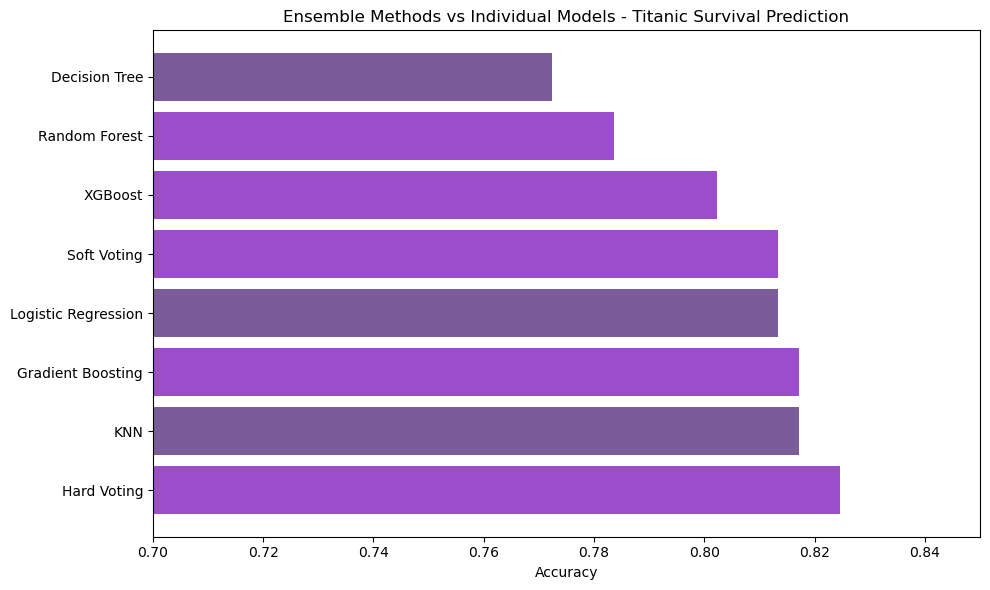

In [23]:
# Visualize the comparison
plt.figure(figsize=(10, 6))
colors = ['#9B4DCA' if 'Voting' in name or 'Forest' in name or 'Boost' in name else '#7B5B9A' 
          for name in sorted_results.keys()]
plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color=colors)
plt.xlabel('Accuracy')
plt.title('Ensemble Methods vs Individual Models - Titanic Survival Prediction')
plt.xlim(0.70, 0.85)
plt.tight_layout()
plt.show()

### Final Takeaways

**What did we learn?**

1. **Ensembles combine models** to (often) get better results than any single model
2. **Voting** is the simplest approach - just combine predictions from different algorithms
3. **Bagging (Random Forest)** trains many of the same model on different data samples
4. **Boosting (Gradient Boosting, XGBoost)** trains models sequentially, learning from mistakes

**Why did simpler methods perform well here?**

The Titanic dataset is small (~890 rows) and well-curated - it's a classic teaching dataset! In this scenario, simpler models can perform surprisingly well.

In the real world, datasets are often:
- **Much larger** (thousands to millions of rows)
- **Messier** (more missing values, noise, outliers)
- **Higher dimensional** (dozens or hundreds of features)
- **More complex** (non-linear relationships between features)

This is where **Random Forest, Gradient Boosting, and XGBoost really shine**. They handle complexity, noise, and large datasets much better than simple voting or individual models. That's why they dominate Kaggle competitions and industry applications!

**Bottom line:** Always experiment with multiple approaches. The best method depends on your specific data.

---

# Part B: Challenge Extension (Optional)

Now it's your turn to push further! Can you beat our best score?

**These challenges are optional** - complete them if you want extra practice or want to explore ensemble methods further.

---

## Challenge 1: Hyperparameter Tuning (Optional)

Try tuning the hyperparameters of Random Forest or Gradient Boosting to improve performance.

**Ideas to try:**
- Random Forest: `max_depth`, `min_samples_split`, `min_samples_leaf`
- Gradient Boosting: `learning_rate`, `max_depth`, `n_estimators`

In [ ]:
# TODO: Experiment with different hyperparameters
# Can you beat our best accuracy?

# Example: Try different max_depth values for Random Forest
# rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# YOUR CODE HERE



## Challenge 2: Feature Engineering (Optional)

Create new features that might help predict survival!

**Ideas to try:**
- `FamilySize` = SibSp + Parch + 1
- `IsAlone` = 1 if FamilySize == 1, else 0
- `FarePerPerson` = Fare / FamilySize
- Age groups (child, adult, elderly)

In [ ]:
# TODO: Create new features and see if they improve your model

# Start with a fresh copy of the data
titanic_fe = titanic[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
titanic_fe['Age'].fillna(titanic_fe['Age'].median(), inplace=True)
titanic_fe['Sex'] = titanic_fe['Sex'].map({'male': 0, 'female': 1})

# YOUR CODE HERE - Add new features!
# Example:
# titanic_fe['FamilySize'] = titanic_fe['SibSp'] + titanic_fe['Parch'] + 1



In [ ]:
# TODO: Train a model with your new features and compare to our baseline

# YOUR CODE HERE



## Challenge 3: Try Different Model Combinations (Optional)

Create your own voting classifier with a different combination of models.

**Ideas to try:**
- Combine Random Forest + Gradient Boosting + Logistic Regression
- Use weighted voting (give more weight to better models)
- Try adding XGBoost to your ensemble

In [ ]:
# TODO: Create your own custom voting ensemble

# YOUR CODE HERE



## Challenge 4: Beat the Leaderboard! (Optional)

Combine everything you've learned. What's the highest accuracy you can achieve?

**Our baseline to beat:** Check the final comparison above!

In [ ]:
# TODO: Your best model - combine feature engineering, tuning, and ensembles!

# YOUR CODE HERE



In [ ]:
# Record your best score here!
your_best_accuracy = None  # Replace with your accuracy

if your_best_accuracy:
    baseline_best = max(sorted_results.values())
    print(f"Your best accuracy: {your_best_accuracy:.4f}")
    print(f"Baseline best: {baseline_best:.4f}")
    if your_best_accuracy > baseline_best:
        print(f"You beat the baseline by {your_best_accuracy - baseline_best:.4f}!")
    else:
        print("Keep experimenting!")

---

## Reflection Questions

Answer these questions based on your experiments:

1. **Which ensemble method performed best? Why do you think that is?**

   *Your answer:*


2. **According to the Random Forest, which features are most important for predicting survival? Does this make sense historically?**

   *Your answer:*


3. **What feature engineering or hyperparameter tuning helped the most?**

   *Your answer:*


4. **When would you choose Bagging (Random Forest) vs Boosting (Gradient Boosting/XGBoost)?**

   *Your answer:*

---

## Great job completing this practice!

You've now have hands-on experience with:
- Voting Classifiers (Hard & Soft)
- Bagging with Random Forest
- Boosting with Gradient Boosting & XGBoost
- Feature engineering and hyperparameter tuning

These are powerful techniques used in real-world machine learning!

---

**Don't forget:**
- Individual Capstone Checkpoint 1 is due Monday, February 2, 2026
- Unit 3 Incremental Capstone releases Thursday!